# Обзор результатов

Здесь я смотрю уже готовые таблицы и графики из `report_results`. Плохие seed не удалялись: в таблицах есть пометки о плохих/нестабильных запусках. FP16 вынесен отдельно и не смешивается с основным сравнением FP32/FP64.

In [10]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)

root = Path.cwd().resolve()
for p in [root] + list(root.parents):
    if (p / "report_results" / "tables" / "selected_cases.csv").exists():
        root = p
        break

table_dir = root / "report_results" / "tables"
fig_dir = root / "report_results" / "figures"
rerun_dir = root / "report_results" / "rerun_plan"

## Выбранные кейсы

Ниже таблица с кейсами, которые удобнее всего брать в отчёт.

In [11]:
selected = pd.read_csv(table_dir / "selected_cases.csv")
show = selected[[
    "case_title", "variant", "why_selected", "fp32_result", "fp64_result", "conclusion", "confidence_label"
]].copy()
conclusion_names = {
    "stable_fp64_better": "FP64 заметно лучше",
    "moderate_fp64_better": "FP64 немного лучше",
    "similar": "FP32 и FP64 близки",
    "fp32_better": "FP32 лучше",
    "unstable_or_seed_sensitive": "зависит от seed",
    "fp16 failed or unstable": "FP16 нестабилен",
}
confidence_names = {
    "strong": "сильная",
    "medium": "средняя",
    "weak_needs_rerun": "нужна проверка",
}
show["conclusion"] = show["conclusion"].map(lambda x: conclusion_names.get(str(x), x))
show["confidence_label"] = show["confidence_label"].map(lambda x: confidence_names.get(str(x), x))
show = show.rename(columns={
    "case_title": "кейс",
    "variant": "вариант",
    "why_selected": "зачем выбран",
    "fp32_result": "FP32",
    "fp64_result": "FP64",
    "conclusion": "вывод",
    "confidence_label": "надёжность",
})
display(show)

,кейс,вариант,зачем выбран,FP32,FP64,вывод,надёжность
0,"Helmholtz, m=12",helmholtz_resample_long,Основной положительный пример: на этом режиме FP64 дал меньшую ошибку по медиане.,"n=2.0, медиана best L2=0.01253, доля плохих=0","n=2.0, медиана best L2=0.002114, доля плохих=0",FP64 заметно лучше,сильная
1,"Convection, beta=50",convection_beta50_wide_lbfgs,"Сложный режим: FP64 выглядит сильно лучше, но запусков мало, поэтому вывод осторожный.","n=1.0, медиана best L2=0.6873, доля плохих=1","n=1.0, медиана best L2=0.007182, доля плохих=0",зависит от seed,нужна проверка
2,"Burgers, nu=0.002",burgers_more_points,Контрольный пример: FP32 и FP64 дали близкие ошибки.,"n=2.0, медиана best L2=0.04878, доля плохих=0","n=2.0, медиана best L2=0.04652, доля плохих=0",FP32 и FP64 близки,сильная
3,"Burgers, nu=0.001",burgers_more_points,"Пример, где FP64 не дал преимущества.","n=2.0, медиана best L2=0.09485, доля плохих=0","n=2.0, медиана best L2=0.17, доля плохих=0",FP32 лучше,сильная
4,"Helmholtz, m=8",helmholtz_main,Пример с заметной зависимостью от seed.,"n=2.0, медиана best L2=0.5019, доля плохих=0.5","n=2.0, медиана best L2=0.0008814, доля плохих=0",зависит от seed,средняя
5,FP16,отдельно,"FP16 вынесен отдельно, потому что в этих запусках он часто давал плохие или невалидные метрики.",NaN,NaN,FP16 нестабилен,средняя


Главный устойчивый положительный кейс - Helmholtz m=12. Convection beta=50 выглядит сильным, но там мало seed, поэтому вывод надо делать осторожно. Burgers я оставляю как пример, где FP64 не всегда даёт преимущество.

## Сравнение FP32 и FP64

Здесь показаны группы сравнений. Основной ориентир - медиана лучшей относительной L2-ошибки, а не лучший отдельный запуск.

In [12]:
comp = pd.read_csv(table_dir / "fp32_fp64_comparison.csv")
cols = [
    "task_name", "main_parameter_name", "main_parameter_value", "variant",
    "fp32_n_valid", "fp64_n_valid", "fp32_median_best_l2", "fp64_median_best_l2",
    "fp64_over_fp32_median", "fp32_bad_rate", "fp64_bad_rate", "conclusion",
]
view = comp[cols].copy()
view["conclusion"] = view["conclusion"].map(lambda x: conclusion_names.get(str(x), x))
view = view.sort_values(["conclusion", "fp64_over_fp32_median"], na_position="last")
view = view.rename(columns={
    "task_name": "задача",
    "main_parameter_name": "параметр",
    "main_parameter_value": "значение",
    "variant": "вариант",
    "fp32_n_valid": "FP32 valid",
    "fp64_n_valid": "FP64 valid",
    "fp32_median_best_l2": "FP32 median L2",
    "fp64_median_best_l2": "FP64 median L2",
    "fp64_over_fp32_median": "FP64/FP32",
    "fp32_bad_rate": "FP32 bad rate",
    "fp64_bad_rate": "FP64 bad rate",
    "conclusion": "вывод",
})
display(view.head(30))

,задача,параметр,значение,вариант,FP32 valid,FP64 valid,FP32 median L2,FP64 median L2,FP64/FP32,FP32 bad rate,FP64 bad rate,вывод
80,helmholtz1d,m,9.000,helmholtz_rs_m9,2,2,0.001059,0.000926,0.873656,0.0,0.0,FP32 и FP64 близки
23,burgers1d,nu,0.010,nu_0p01,3,3,0.045218,0.043015,0.951271,0.0,0.0,FP32 и FP64 близки
21,burgers1d,nu,0.002,burgers_more_points,2,2,0.048779,0.046524,0.953769,0.0,0.0,FP32 и FP64 близки
24,burgers1d,nu,0.100,nu_0p1,3,3,0.019673,0.019953,1.014223,0.0,0.0,FP32 и FP64 близки
17,burgers1d,nu,0.010,burgers_hard_nu_0p01,2,2,0.041614,0.042601,1.023708,0.0,0.0,FP32 и FP64 близки
16,burgers1d,nu,0.005,burgers_hard_nu_0p005,2,2,0.046916,0.050572,1.077924,0.0,0.0,FP32 и FP64 близки
20,burgers1d,nu,0.001,burgers_more_points,2,2,0.094845,0.169969,1.792065,0.0,0.0,FP32 лучше
73,helmholtz1d,m,10.000,helmholtz_rs_m10,2,2,0.001598,0.003004,1.879420,0.0,0.0,FP32 лучше
77,helmholtz1d,m,6.000,helmholtz_rs_m6,2,2,0.000268,0.000507,1.891385,0.0,0.0,FP32 лучше
81,helmholtz1d,m,8.000,more_points_soft,2,2,0.009189,0.023950,2.606363,0.0,0.0,FP32 лучше


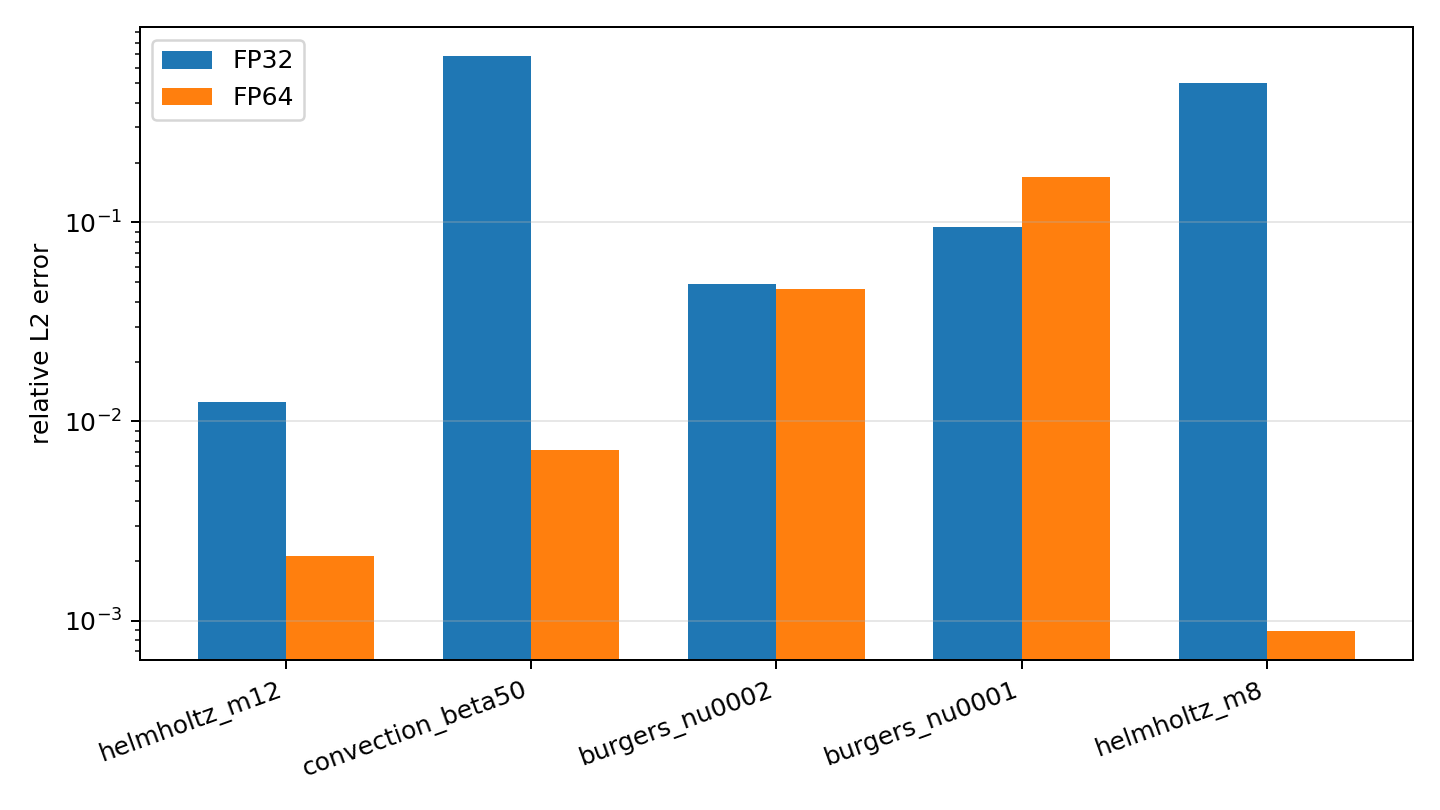

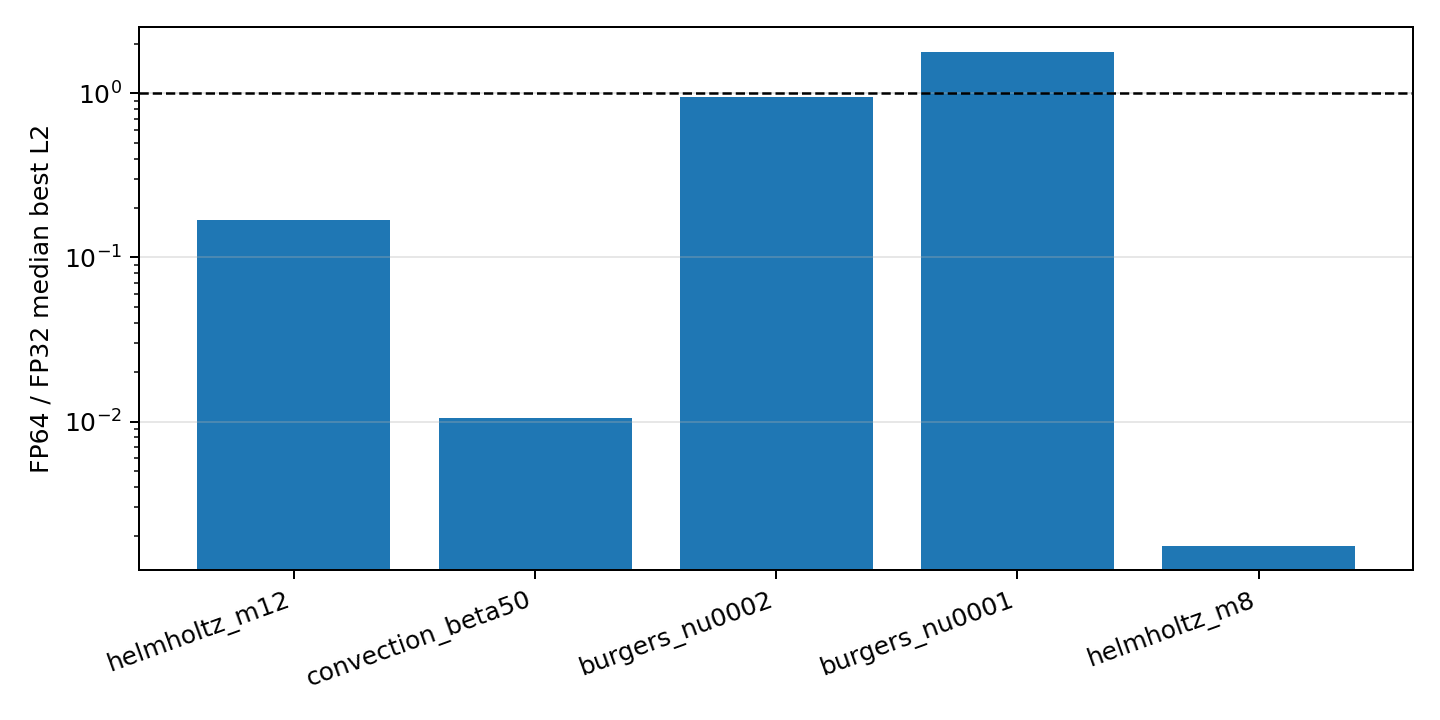

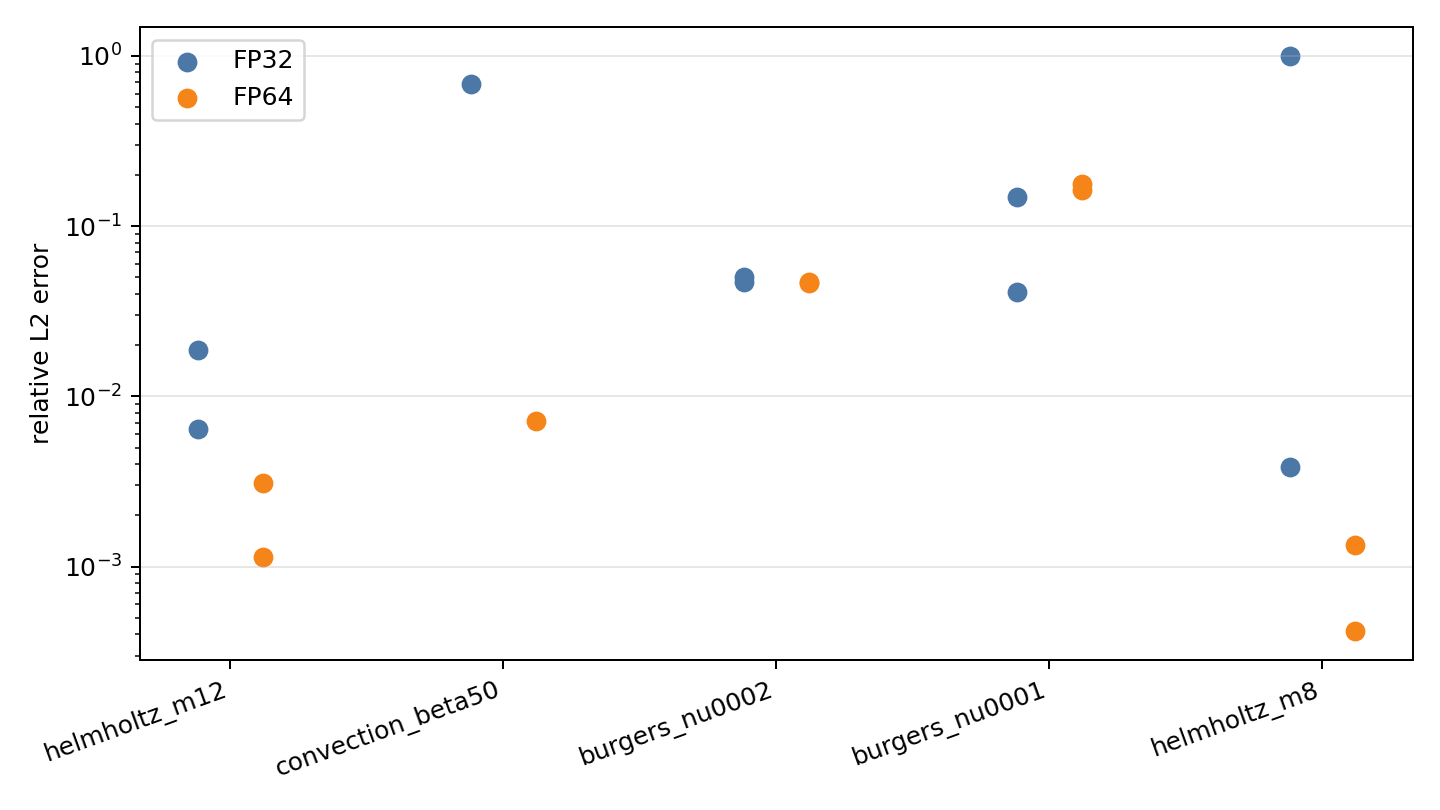

In [13]:
for name in [
    "report_best_l2_by_dtype.png",
    "report_fp64_fp32_ratio.png",
    "report_seed_scatter.png",
]:
    display(Image(filename=str(fig_dir / name)))

По графикам видно, что FP64 может давать меньшую ошибку на части Helmholtz-запусков. Но есть и режимы, где разница небольшая или FP32 оказывается не хуже. Поэтому общий вывод нельзя формулировать как “FP64 всегда лучше”.

## FP16

FP16 я не использую как равноправный устойчивый вариант, потому что большинство запусков плохие или невалидные.

In [14]:
fp16 = pd.read_csv(table_dir / "fp16_summary.csv")
reason_col = "typical_" + "fail" + "ure_reason"
reason_names = {
    "runtime_error": "ошибка запуска",
    "nan_metric": "NaN в метриках",
    "inf_metric": "inf в метриках",
    "high_best_l2": "большая best L2",
    "high_final_l2": "большая final L2",
    "missing_metrics": "нет метрик",
    "ok": "без явной ошибки",
}
cols = ["task_name", "main_parameter_name", "main_parameter_value", "variant", "n_total", "n_valid", "n_bad", "bad_rate", reason_col]
show = fp16[cols].copy()
show[reason_col] = show[reason_col].map(lambda x: reason_names.get(str(x), x))
show = show.rename(columns={
    "task_name": "задача",
    "main_parameter_name": "параметр",
    "main_parameter_value": "значение",
    "variant": "вариант",
    "n_total": "всего",
    "n_valid": "валидных",
    "n_bad": "плохих",
    "bad_rate": "доля плохих",
    reason_col: "типичная причина",
})
display(show)

,задача,параметр,значение,вариант,всего,валидных,плохих,доля плохих,типичная причина
0,burgers1d,nu,NaN,burgers_main_nu0p001,2,0,2,1.0,ошибка запуска
1,burgers1d,nu,NaN,burgers_main_nu0p002,2,0,2,1.0,ошибка запуска
2,burgers1d,nu,0.001,burgers_more_points,2,0,2,1.0,NaN в метриках
3,burgers1d,nu,0.002,burgers_more_points,2,0,2,1.0,NaN в метриках
4,convection1d,beta,NaN,convection_beta30_beta30p0,2,0,2,1.0,ошибка запуска
5,convection1d,beta,30.000,convection_beta30_lbfgs_grid,2,1,2,1.0,большая best L2
6,convection1d,beta,NaN,convection_beta50_beta50p0,1,0,1,1.0,ошибка запуска
7,convection1d,beta,50.000,convection_beta50_wide_lbfgs,1,0,1,1.0,NaN в метриках
8,helmholtz1d,m,NaN,helmholtz_main_m12,2,0,2,1.0,ошибка запуска
9,helmholtz1d,m,NaN,helmholtz_main_m8,2,0,2,1.0,ошибка запуска


## Кривые обучения

Для выбранных кейсов ниже показаны loss и relative L2 error по шагам обучения.

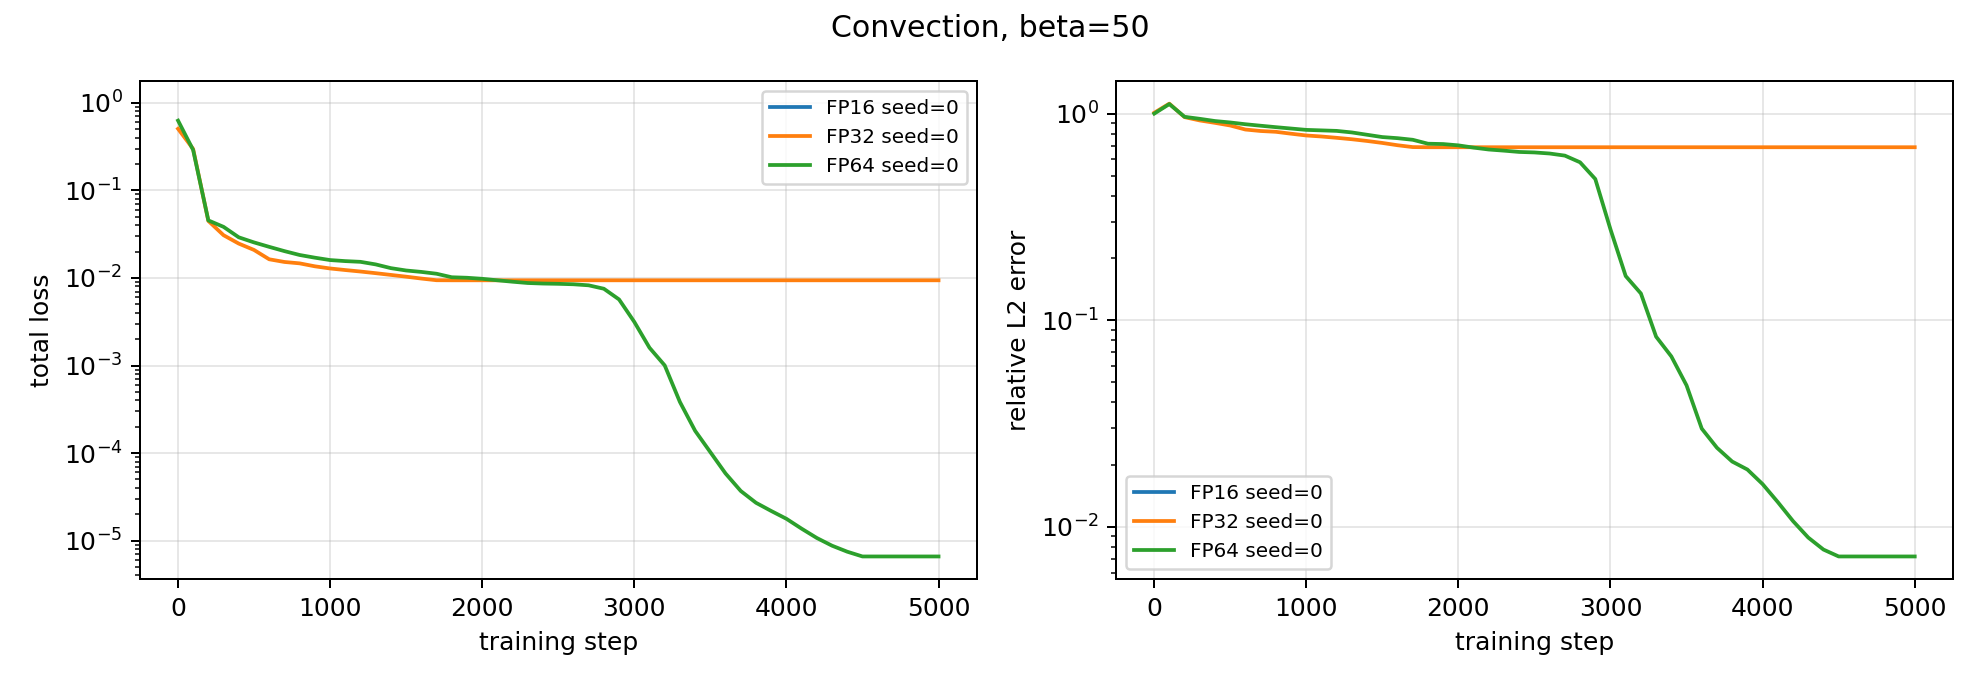

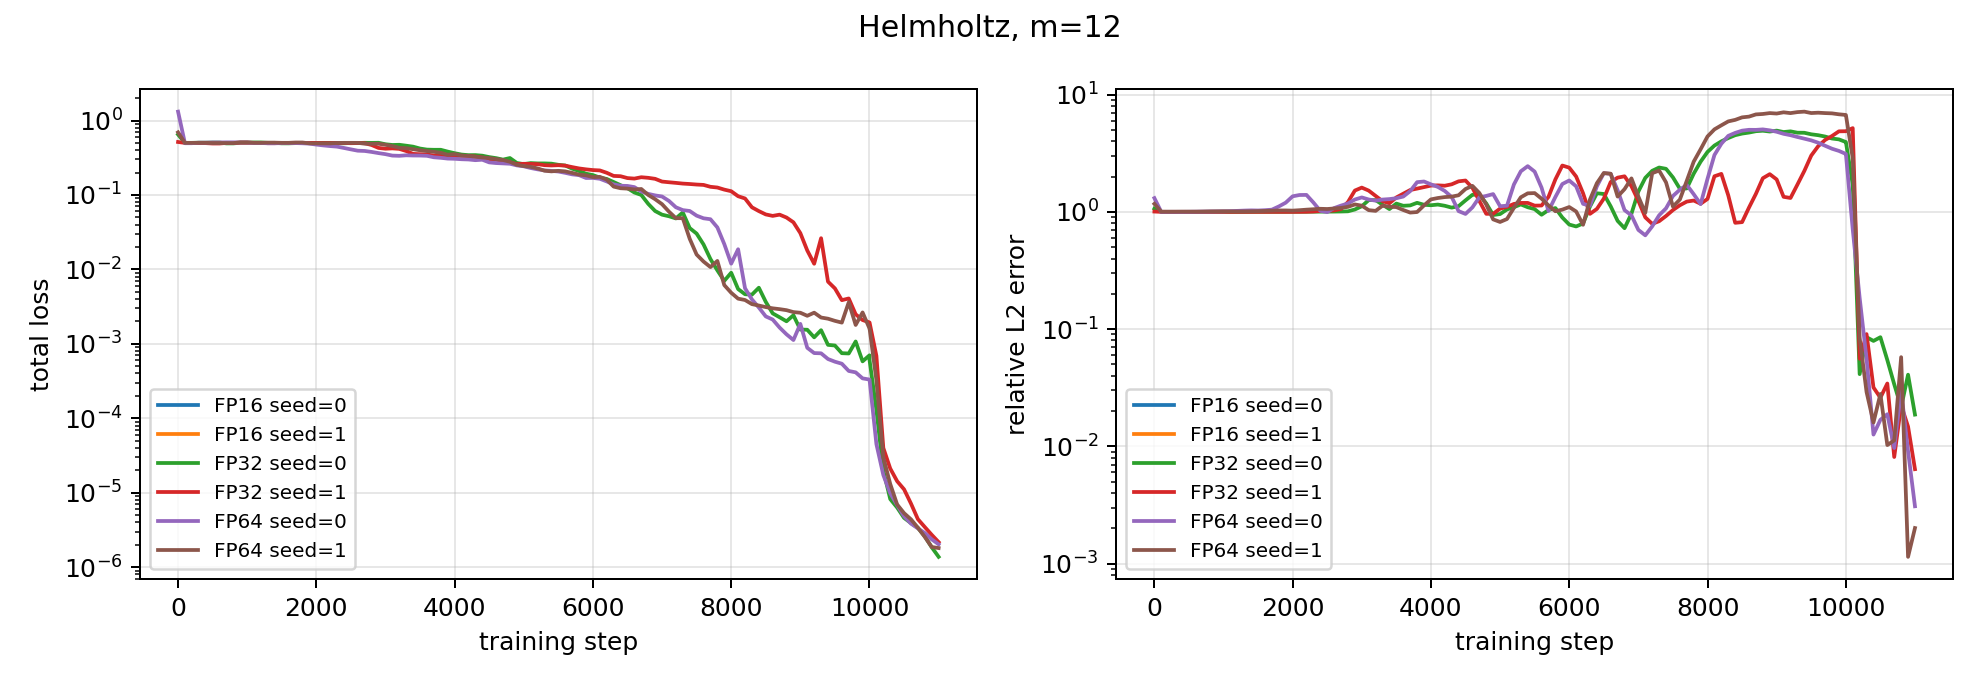

In [15]:
for name in [
    "report_convection_beta50_curves.png",
    "report_helmholtz_m12_curves.png",
]:
    display(Image(filename=str(fig_dir / name)))

На Helmholtz m=12 видно более аккуратное поведение FP64. На Convection beta=50 результат интересный, но из-за малого числа seed его лучше считать сложным примером, а не полностью устойчивым выводом.

## Что ещё можно дозапустить

Полный перезапуск не нужен. Если нужно улучшить отчёт картинками, достаточно нескольких небольших проверок.

In [16]:
text = (rerun_dir / "missing_artifacts.md").read_text()
display(Markdown(text))

# Чего не хватает для аккуратного отчёта

## Уже есть

- таблицы best/final relative L2;
- сравнение FP32 и FP64;
- отдельная таблица по FP16;
- графики loss/L2 для выбранных кейсов;
- выбранные кейсы для отчёта.

## Ещё желательно добавить

- MAE/RMSE для выбранных convection-запусков;
- карты exact / prediction / error для convection beta=50;
- один selected check для FP16 на convection beta=50, если нужен пример неудачного запуска.

## Большой перезапуск

Большой перезапуск всех экспериментов не нужен.

## Минимальные дозапуски

- convection_beta50_fp32_seed0
- convection_beta50_fp64_seed0
- convection_beta50_fp16_seed0

Перезапуск всех 33 runs для отчёта не нужен.
